# Mobility of Florida

On July 27, 2025, Florida experienced an [extreme heatwave](https://www.scientificamerican.com/article/tampa-breaks-heat-record-as-heat-dome-bakes-eastern-u-s/), with Tampa setting temperature record. We aim to gain insights into how extreme weather events like this effect mobility in an area.

Florida has 9 [**Metropolitan Statistical Areas**](https://en.wikipedia.org/wiki/Metropolitan_statistical_area) (msa) in the US top 100, that we focus on.
* North Port-Bradenton-Sarasota, FL
* Cape Coral-Fort Myers, FL,
* Jacksonville, FL,
* Palm Bay-Melbourne-Titusville, FL,
* Lakeland-Winter Haven, FL,
* Miami-Fort Lauderdale-West Palm Beach, FL,
* Orlando-Kissimmee-Sanford, FL,
* Tampa-St. Petersburg-Clearwater, FL,
* Deltona-Daytona Beach-Ormond Beach, FL

With Advan Research's *Weekly Patterns Plus*, we have information on weekly visit flows between home [*Census Block Groups*](https://en.wikipedia.org/wiki/Census_block_group) (CBGs) and destination Points of Interest (POIs) over time. For each pairing of POI $p$ and block group $b$, we compute spatial distance $d_{i,j}$ between the two. Each observation in the dataset is the weekly number of visitors between POI $p$ and block group $b$. We compute the average travel distance and [radius of gyration](https://en.wikipedia.org/wiki/Radius_of_gyration) for each block group on a weekly basis, and aggregate it on a msa level using a weighted average and median of block group-level metric.

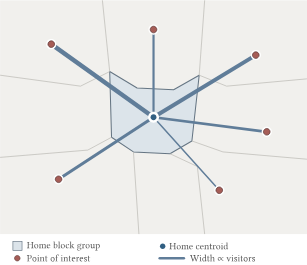

In [1]:
from datetime import datetime, timedelta, date
import math

import duckdb
import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import orjson
import pandas as pd
import polars as pl
import seaborn as sns
import shapely
from tqdm import tqdm

from wpp import data, db, plot
from wpp.utils import project_root

In [2]:
# config
sns.set_theme(style="ticks")
pl.Config.set_engine_affinity("streaming")

root = project_root()
db_path = root / "wpp.duckdb"
con = db.connect(db_path)

In [3]:
events = data.get_climate_events()
event_date = date(2025, 7, 27)
baseline_start = event_date - timedelta(weeks=3)

In [60]:
visits_query = """
    WITH bg AS (
        SELECT 
            GEOID, CBSAFP, CBSA_NAME, CBSA_POP_RANK, CBSA_POP_2025, CBSA_POP_RANK <= 100 AS TOP_100
        FROM block_groups_cbsa
        WHERE LSAD = 'M1'
          --AND CBSA_POP_RANK <= 100
          --AND STATEFP = '12'
    ), x AS (
        SELECT 
            bgv.*, CBSAFP, CBSA_NAME, CBSA_POP_RANK, CBSA_POP_2025, TOP_100
        FROM block_group_visits_enhanced bgv
        JOIN bg ON bgv.HOME_GEOID = bg.GEOID
    )
    SELECT 
        DATE_RANGE_START, CBSA_NAME, CBSA_POP_RANK, CBSA_POP_2025, TOP_100,
        SUM(VISITOR_COUNTS) AS VISITOR_COUNTS,
        SUM(VISITOR_COUNTS * DIST) / SUM(VISITOR_COUNTS) AS AVG_DIST
    FROM x
    GROUP BY 1, 2, 3, 4, 5

"""
df = con.sql(visits_query).pl().with_columns(
    pl.when(pl.col("CBSA_NAME").str.ends_with(", FL")).then(pl.lit("Florida")).otherwise(pl.lit("Other")).alias("IS_FLORIDA"),
    pl.when(pl.col("CBSA_POP_RANK") <= 5).then(pl.col("CBSA_NAME")).otherwise(pl.lit("Other")).alias("TOP_NAME")
).with_columns(
    pl.col("TOP_NAME").str.split(",").list[-1].str.strip_chars().alias("SHORT_NAME")
)
df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DATE_RANGE_START,CBSA_NAME,CBSA_POP_RANK,CBSA_POP_2025,TOP_100,VISITOR_COUNTS,AVG_DIST,IS_FLORIDA,TOP_NAME,SHORT_NAME
datetime[μs],str,i64,i64,bool,"decimal[38,0]",f64,str,str,str
2025-01-06 00:00:00,"""Birmingham, AL""",48,1197766,true,37003353,32226.85973,"""Other""","""Other""","""Other"""
2025-01-06 00:00:00,"""Phoenix-Mesa-Chandler, AZ""",10,5228938,true,106403150,65990.144967,"""Other""","""Other""","""Other"""
2025-01-06 00:00:00,"""Little Rock-North Little Rock-…",80,777607,true,23000372,38753.88431,"""Other""","""Other""","""Other"""
2025-01-06 00:00:00,"""Dalton, GA""",294,147819,false,4214030,22332.754397,"""Other""","""Other""","""Other"""
2025-01-06 00:00:00,"""Terre Haute, IN""",262,169241,false,3987291,42255.747442,"""Other""","""Other""","""Other"""


(np.float64(20076.15), np.float64(20468.85), np.float64(0.0), np.float64(1.0))

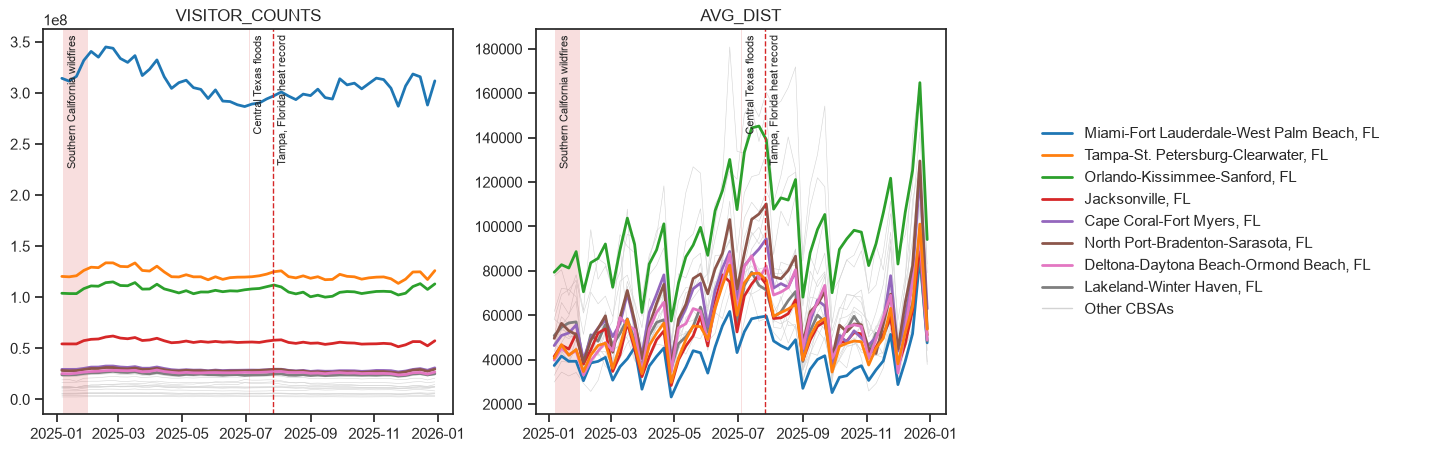

In [66]:
df = df.sort("DATE_RANGE_START")

top = (
    df.filter(pl.col("IS_FLORIDA") == "Florida")
      .group_by("CBSA_NAME")
      .agg(pl.col("VISITOR_COUNTS").mean())
      .top_k(8, by="VISITOR_COUNTS")["CBSA_NAME"]
      .to_list()
)
palette = dict(zip(top, sns.color_palette("tab10", len(top))))

background = df.filter((~pl.col("CBSA_NAME").is_in(top)) & (pl.col("IS_FLORIDA") == "Florida"))
highlight = df.filter((pl.col("CBSA_NAME").is_in(top)) & (pl.col("IS_FLORIDA") == "Florida"))

fig, axes = plt.subplots(1, 3, sharex=True, figsize=(18, 5))

for ax, y in zip(axes[:2], ["VISITOR_COUNTS", "AVG_DIST"]):
    # gray background lines
    for _, g in background.group_by("CBSA_NAME", maintain_order=True):
        ax.plot(g["DATE_RANGE_START"], g[y], color="lightgray", lw=0.4, zorder=1)
    # highlighted lines
    for (name,), g in highlight.group_by("CBSA_NAME", maintain_order=True):
        ax.plot(g["DATE_RANGE_START"], g[y], color=palette[name], lw=2, zorder=2)
    ax.set_title(y)
    plot.plot_events(ax, events)

handles = [Line2D([0], [0], color=c, lw=2, label=n) for n, c in palette.items()]
handles.append(Line2D([0], [0], color="lightgray", lw=1, label="Other CBSAs"))
axes[2].legend(handles=handles, loc="center left", frameon=False)
axes[2].axis("off")

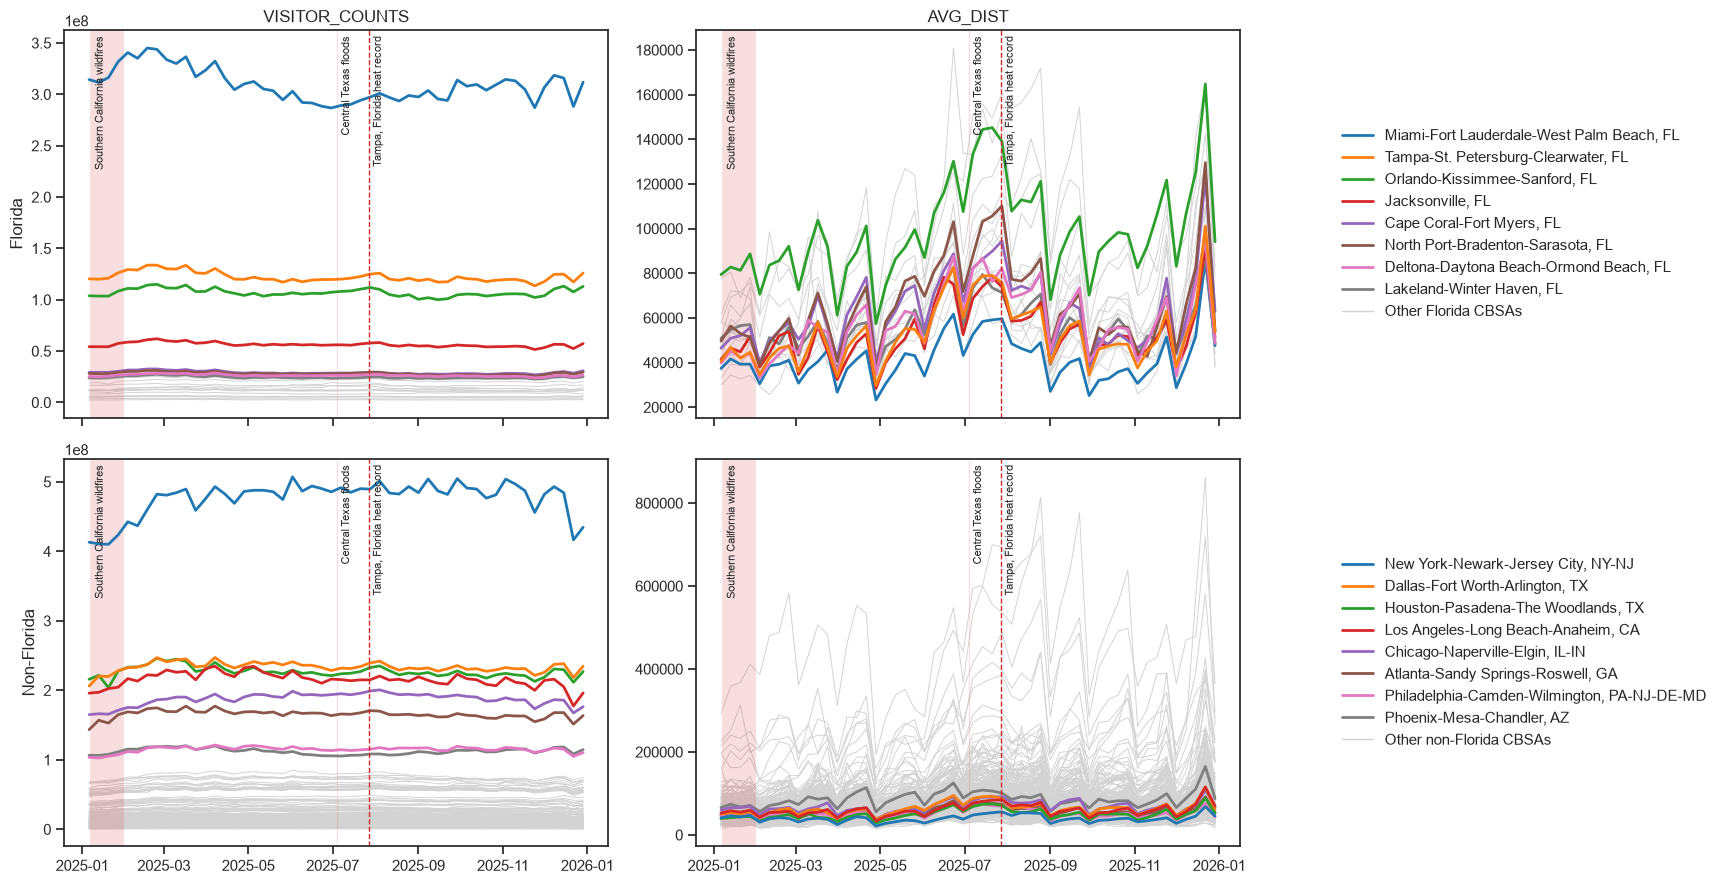

In [63]:
metrics = ["VISITOR_COUNTS", "AVG_DIST"]

def plot_row(sub, axes_row, n_top=8, other_label="Other CBSAs"):
    top = (
        sub.group_by("CBSA_NAME")
           .agg(pl.col("VISITOR_COUNTS").mean())
           .top_k(n_top, by="VISITOR_COUNTS")["CBSA_NAME"]
           .to_list()
    )
    palette = dict(zip(top, sns.color_palette("tab10", len(top))))

    background = sub.filter(~pl.col("CBSA_NAME").is_in(top))
    highlight = sub.filter(pl.col("CBSA_NAME").is_in(top))

    for ax, y in zip(axes_row[:2], metrics):
        for _, g in background.group_by("CBSA_NAME", maintain_order=True):
            ax.plot(g["DATE_RANGE_START"], g[y], color="lightgray", lw=0.7, zorder=1)
        for (name,), g in highlight.group_by("CBSA_NAME", maintain_order=True):
            ax.plot(g["DATE_RANGE_START"], g[y], color=palette[name], lw=2, zorder=2)
        plot.plot_events(ax, events)

    # last column is the legend panel
    handles = [Line2D([0], [0], color=c, lw=2, label=n) for n, c in palette.items()]
    handles.append(Line2D([0], [0], color="lightgray", lw=1, label=other_label))
    axes_row[2].legend(handles=handles, loc="center left", frameon=False)
    axes_row[2].axis("off")


fig, axes = plt.subplots(2, 3, sharex=True, figsize=(18, 9),
                         gridspec_kw={"width_ratios": [1, 1, 0.7]})

plot_row(df.filter(pl.col("IS_FLORIDA") == "Florida"), axes[0], other_label="Other Florida CBSAs")
plot_row(df.filter(pl.col("IS_FLORIDA") == "Other"), axes[1], other_label="Other non-Florida CBSAs")

# titles on the top row only, row labels on the left
for ax, y in zip(axes[0, :2], metrics):
    ax.set_title(y)
axes[0, 0].set_ylabel("Florida")
axes[1, 0].set_ylabel("Non-Florida")

fig.tight_layout()

## Trip length distribution by msa

In [3]:
dist_create_query = """
CREATE OR REPLACE TABLE tmp AS
    WITH bg AS (
        SELECT 
            GEOID, CBSAFP, CBSA_NAME, CBSA_POP_2025
        FROM block_groups_cbsa
        WHERE LSAD = 'M1'
          AND (
            CBSA_POP_RANK <= 50 OR
            CBSA_NAME LIKE '%, FL'
            )
    ), x AS (
        SELECT 
            DATE_RANGE_START, HOME_GEOID, ID_STORE, CBSA_NAME, 
            VISITOR_COUNTS, DIST
        FROM block_group_visits_enhanced bgv
        JOIN bg ON bgv.HOME_GEOID = bg.GEOID
    )
    SELECT 
        DATE_RANGE_START, HOME_GEOID, ID_STORE, CBSA_NAME, 
        VISITOR_COUNTS, DIST
    FROM x
"""
con.execute(dist_query)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

AttributeError: 'NoneType' object has no attribute 'pl'

In [ ]:
ccdf_query = """
    WITH dists AS (
        SELECT
            CBSA_NAME,
            DIST,
            SUM(VISITOR_COUNTS) AS n
        FROM tmp
        WHERE DIST > 0
        GROUP BY 1, 2
    ),
    totals AS (
        SELECT
            CBSA_NAME,
            SUM(n) AS total_n
        FROM dists
        GROUP BY 1
    )
    SELECT
        d.CBSA_NAME,
        d.DIST,
        SUM(n) OVER (
            PARTITION BY d.CBSA_NAME
            ORDER BY d.DIST DESC
        ) / total_n AS ccdf
    FROM dists d
    JOIN totals t USING (CBSA_NAME)
"""
ccdf = con.sql(ccdf_query).pl()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

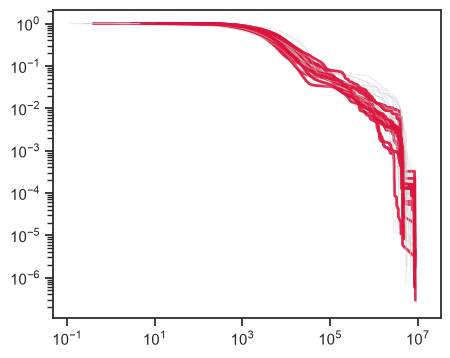

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))

for (cbsa, ), g in ccdf.group_by("CBSA_NAME", maintain_order=True):
    is_fl = cbsa.endswith(", FL")

    ax.plot(
        g["DIST"],
        g["ccdf"],
        color="crimson" if is_fl else "0.8",
        lw=2 if is_fl else 0.75,
        alpha=0.9 if is_fl else 0.4,
    )

ax.set_xscale("log")
ax.set_yscale("log")

In [56]:
BIN_WIDTH = 0.05  # must match 1/20 in the SQL

hist = con.sql("""
    SELECT
        CBSA_NAME,
        FLOOR(LOG10(DIST) * 20) / 20 AS log_bin,
        SUM(VISITOR_COUNTS) AS n
    FROM tmp
    WHERE DIST > 0
    GROUP BY 1, 2
""").pl()

hist = hist.with_columns(
    (pl.col("n").cast(pl.Float64) / pl.col("n").sum().over("CBSA_NAME")).alias("share"),
    pl.col("CBSA_NAME").str.ends_with(", FL").alias("IS_FLORIDA")
).sort("CBSA_NAME", "log_bin")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [68]:
ccdf = (
    hist.sort("log_bin")
    .with_columns(
        pl.col("share")
            .reverse()
            .cum_sum()
            .reverse()
            .alias("ccdf")
    )
)

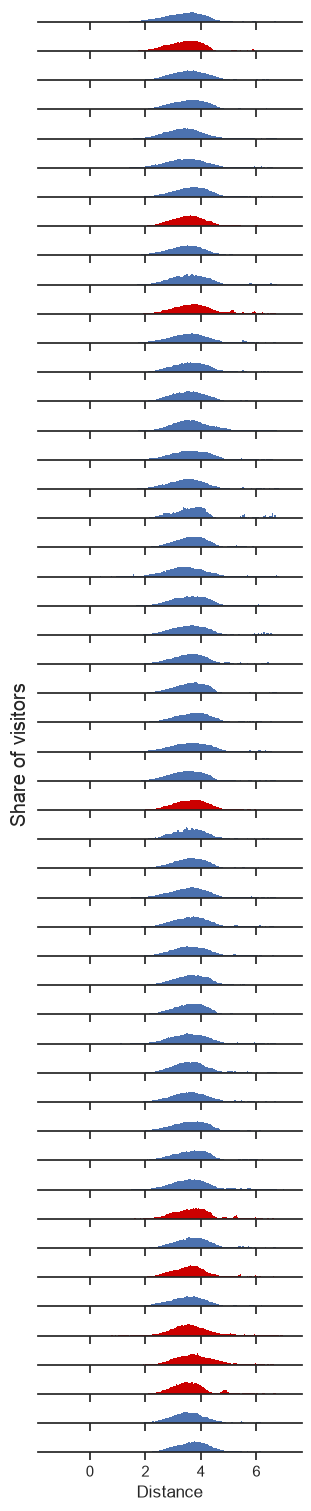

In [66]:
cbsas = (
    hist.group_by("CBSA_NAME", "IS_FLORIDA")
        .agg(pl.col("n").sum())
        .sort("n", descending=True)
        .head(50)["CBSA_NAME"]
        .to_list()
)

N = len(cbsas)
fig, axes = plt.subplots(
    N, 1, sharex=True, sharey=True,
    figsize=(3, 0.3 * N), squeeze=False, constrained_layout=True,
)
axes = axes[:, 0]

for ax, cbsa in zip(axes, cbsas):
    g = hist.filter(pl.col("CBSA_NAME") == cbsa)
    color = "#C00" if g["IS_FLORIDA"][0] else "C0"
    ax.bar(
        g["log_bin"].to_numpy(), g["share"].to_numpy(),
        width=BIN_WIDTH, align="edge", color=color, edgecolor="none",
    )
    # ax.set_title(cbsa, loc="left", fontsize=9)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.set_yticks([])

axes[-1].set_xlabel("Distance")
fig.supylabel("Share of visitors")
plt.show()